# Analyzing Job Skills with LAiSER

This notebook helps job seekers understand the most in-demand skills for their target roles by extracting and visualizing skills from job descriptions.

- Author: Satya Phanindra Kumar Kalaga
- Date: September 2025

## 1. Setup

First, let's install the `laiser` package and other necessary libraries.

In [ ]:
!pip install laiser pandas matplotlib wordcloud torch

## 2. Import Libraries

In [ ]:
import torch
import pandas as pd
from laiser.skill_extractor_refactored import SkillExtractorRefactored
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## 3. Initialize the Skill Extractor

We'll initialize the `SkillExtractorRefactored` from the `laiser` package. You will need to provide your Hugging Face model ID and token. For this example, we will use a CPU-only environment.

In [ ]:
# Replace with your Hugging Face model ID and token
model_id = "gemini"  # e.g., "mistralai/Mistral-7B-Instruct-v0.1"
api_key = "your-key"

try:
    se = SkillExtractorRefactored(model_id=model_id, api_key=api_key, use_gpu=False)
    print("Skill Extractor initialized successfully!")
except Exception as e:
    print(f"Error initializing Skill Extractor: {e}")

Using Gemini API for skill extraction...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Skill Extractor initialized successfully!


## 4. Load Job Postings Data

We'll load a sample dataset of job postings from a CSV file. This dataset contains job descriptions that we will analyze.

In [ ]:
url = 'https://raw.githubusercontent.com/LAiSER-Software/datasets/refs/heads/master/jobs-data/linkedin_jobs_sample_36rows.csv'
job_postings = pd.read_csv(url)
job_postings = job_postings[['description', 'job_id']].dropna()
print("Job postings data loaded successfully:")
job_postings.head()

Job postings data loaded successfully:


,description,job_id
0,\nJob description\nDescription\n\nDo you have ...,1
1,\nJob description\nAre you interested in worki...,2
2,\nJob description\nWeb Developer (Programmer)\...,3
3,\nJob highlights\n\nQualifications\n• Ability ...,4
4,\nAbout the role:\n\nHealthcare Legal Solution...,5


## 5. Extract Skills from Job Descriptions

Now, we'll use the `extract_and_align` method from the `laiser` skill extractor to identify skills in the job descriptions.

In [ ]:
try:
    extracted_skills = se.extract_and_align(
        job_postings,
        id_column="job_id",
        text_columns=["description"],
        input_type='job_desc'
    )
    print("Skills extracted successfully!")
    print(extracted_skills.head())
except Exception as e:
    print(f"Error during skill extraction: {e}")

[Gemini] Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10, model: gemini-2.5-flash-lite
Please retry in 10.795211477s.


[Gemini] Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10, model: gemini-2.5-flash-lite
Please retry in 10.38309777s.


[Gemini] Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10, model: gemini-2.5-flash-lite
Please retry in 10.007163493s.


[Gemini] Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10, model: gemini-2.5-flash-lite
Please retry in 9.61415516s.


[Gemini] Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10, model: gemini-2.5-flash-lite
Please retry in 9.23505184s.


...

[Gemini] Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10, model: gemini-2.5-flash-lite
Please retry in 58.754521151s.


[Gemini] Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10, model: gemini-2.5-flash-lite
Please retry in 58.363965255s.


[Gemini] Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10, model: gemini-2.5-flash-lite
Please retry in 57.983303362s.


[Gemini] Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10, model: gemini-2.5-flash-lite
Please retry in 57.572023213s.


[Gemini] Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10, model: gemini-2.5-flash-lite
Please retry in 57.154313523s.
Skills extracted successfully!
  Research ID                    Raw Skill                   Taxonomy Skill  \
0           1       Linux/Unix environment                             UNIX   
1           1  object oriented programming  use object-oriented programming   
2           1              user interfaces            design user interface   
3           1                   Typescript                       TypeScript   
4       

## 6. Visualize the Extracted Skills

Let's visualize the most common skills found in the job postings. A bar chart and a word cloud are great ways to see which skills are most in-demand.

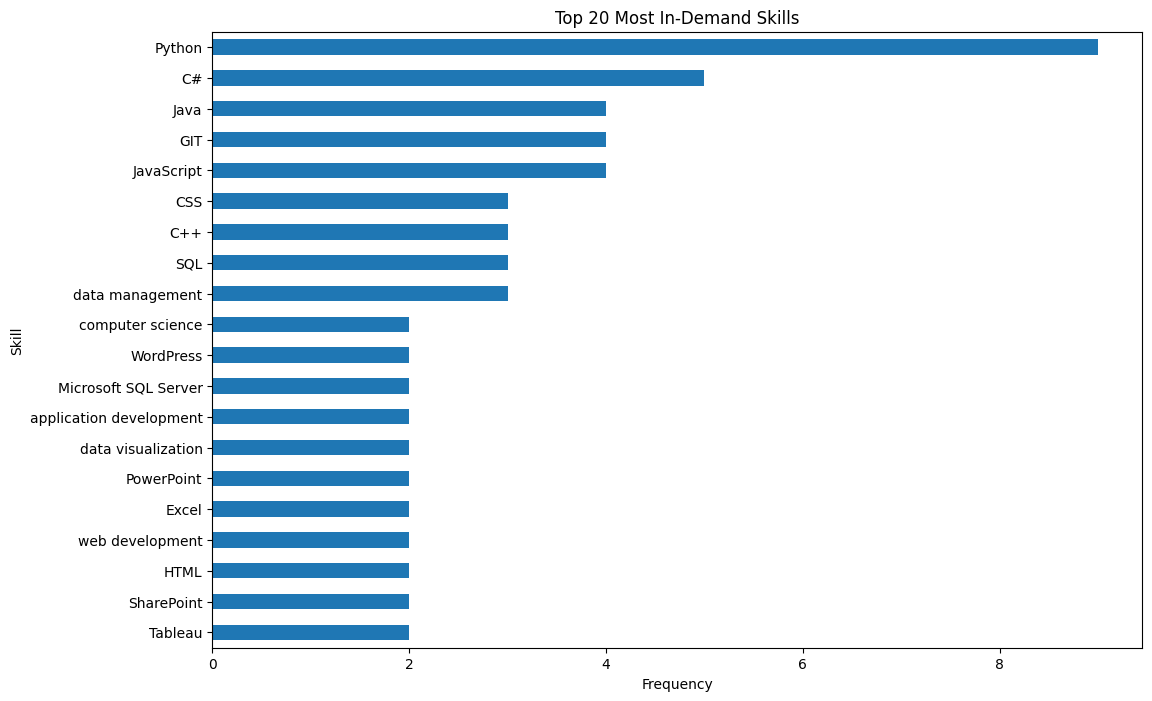

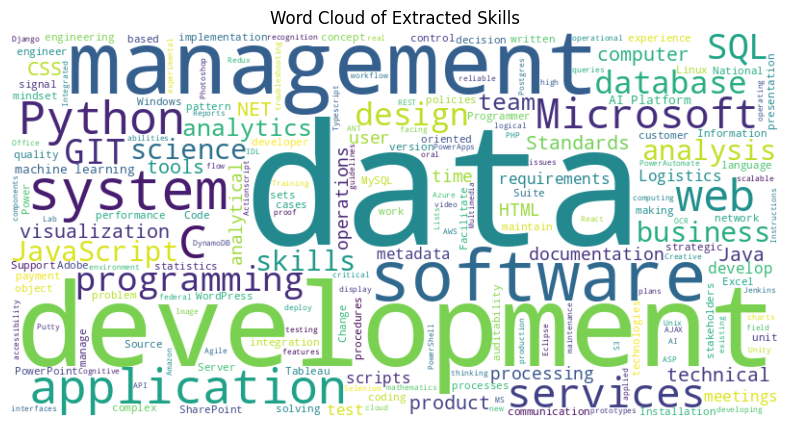

In [ ]:
if 'extracted_skills' in locals() and not extracted_skills.empty:
    skill_counts = extracted_skills['Raw Skill'].value_counts().nlargest(20)

    # Bar Chart
    plt.figure(figsize=(12, 8))
    skill_counts.sort_values().plot(kind='barh')
    plt.title('Top 20 Most In-Demand Skills')
    plt.xlabel('Frequency')
    plt.ylabel('Skill')
    plt.show()

    # Word Cloud
    all_skills = ' '.join(extracted_skills['Raw Skill'].dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_skills)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Extracted Skills')
    plt.show()
else:
    print("No skills were extracted to visualize.")